In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df=pd.read_csv('Algerian_forest_fires_dataset_UPDATE.csv',header=1)

In [4]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


In [5]:
df.columns=df.columns.str.strip()
divider=df[df['Classes'].isna()].index[0]
df.shape

(246, 14)

In [6]:
df.loc[0:122,'Region']=0 # 0 for 
df.loc[122:,'Region']=1 #1 for sidi-bel


In [7]:
df.dropna(inplace=True)

In [8]:
df['Date']=df['day']+'-'+df['month']+'-'+df['year']
df['Classes']=df['Classes'].str.strip()

In [9]:
df['Classes']=df['Classes'].map({'fire':1,'not fire':0})

In [10]:
df=df.drop(index=123).reset_index()
df.drop('index',axis=1,inplace=True)

In [11]:
int_cols=df.columns[0:6]
for col in int_cols:
    df[col] = df[col].astype('Int64')

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          243 non-null    Int64  
 1   month        243 non-null    Int64  
 2   year         243 non-null    Int64  
 3   Temperature  243 non-null    Int64  
 4   RH           243 non-null    Int64  
 5   Ws           243 non-null    Int64  
 6   Rain         243 non-null    str    
 7   FFMC         243 non-null    str    
 8   DMC          243 non-null    str    
 9   DC           243 non-null    str    
 10  ISI          243 non-null    str    
 11  BUI          243 non-null    str    
 12  FWI          243 non-null    str    
 13  Classes      243 non-null    float64
 14  Region       243 non-null    float64
 15  Date         243 non-null    str    
dtypes: Int64(6), float64(2), str(8)
memory usage: 39.8 KB


In [13]:
float_cols=['Rain', 'FFMC','DMC', 'DC', 'ISI', 'BUI', 'FWI']
for col in float_cols:
    df[col] = df[col].astype(float)

In [14]:
df['Classes']=df['Classes'].astype(int)

In [15]:
df['Region']=df['Region'].astype(int)

In [16]:
df.to_csv('Algerian_forest_fires_CLEANED.csv',index=False)

In [ ]:
df=pd.read_csv('Algerian_forest_fires_CLEANED.csv')
df_copy=df.copy()
df=df.drop(['day','month','year','Date'],axis=1)


In [30]:
df.columns

Index(['Temperature', 'RH', 'Ws', 'Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI',
       'FWI', 'Classes', 'Region'],
      dtype='str')

In [18]:
corr=df.corr()
corr.iloc[0,1]

np.float64(-0.651400338709241)

<Axes: >

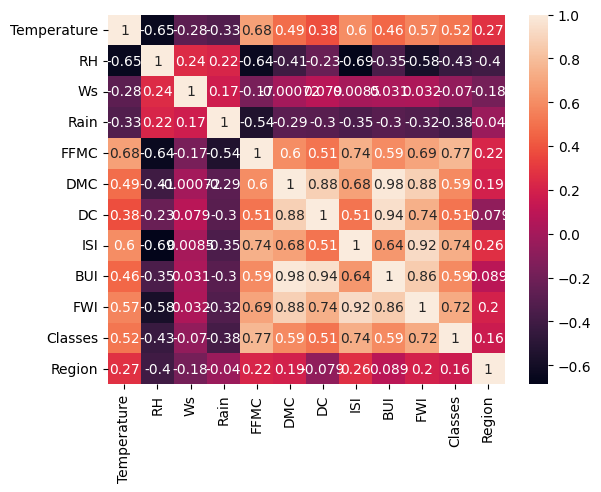

In [19]:
sns.heatmap(corr,annot=True)

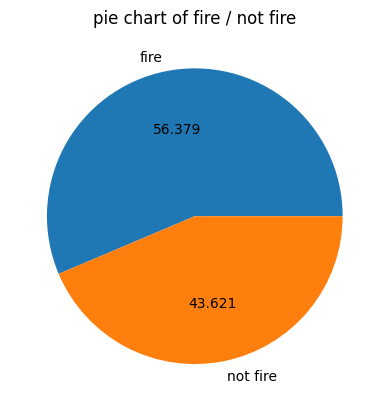

In [49]:
plt.pie(df['Classes'].value_counts(),normalize=True,labels=['fire','not fire'],autopct='%1.3f')
plt.title('pie chart of fire / not fire')
plt.show()

array([[<Axes: title={'center': 'Temperature'}>,
        <Axes: title={'center': 'RH'}>, <Axes: title={'center': 'Ws'}>],
       [<Axes: title={'center': 'Rain'}>,
        <Axes: title={'center': 'FFMC'}>,
        <Axes: title={'center': 'DMC'}>],
       [<Axes: title={'center': 'DC'}>, <Axes: title={'center': 'ISI'}>,
        <Axes: title={'center': 'BUI'}>],
       [<Axes: title={'center': 'FWI'}>,
        <Axes: title={'center': 'Classes'}>,
        <Axes: title={'center': 'Region'}>]], dtype=object)

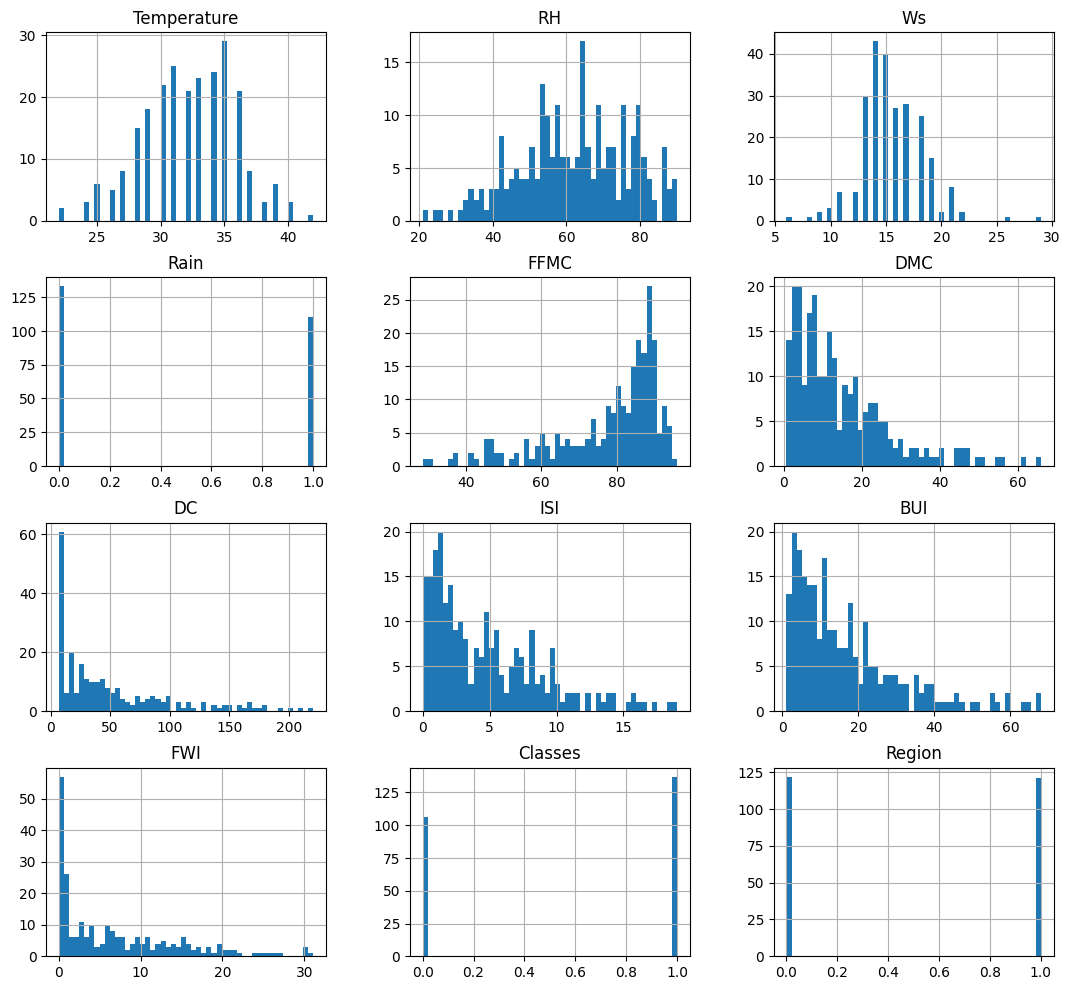

In [50]:
df.hist(bins=50,figsize=(13,12))

In [51]:

df['Rain']=df['Rain'].apply(lambda x: x!=0).map({False:0,True:1})

In [52]:
df['Rain'].value_counts()

Rain
0    133
1    110
Name: count, dtype: int64

<Axes: xlabel='month', ylabel='count'>

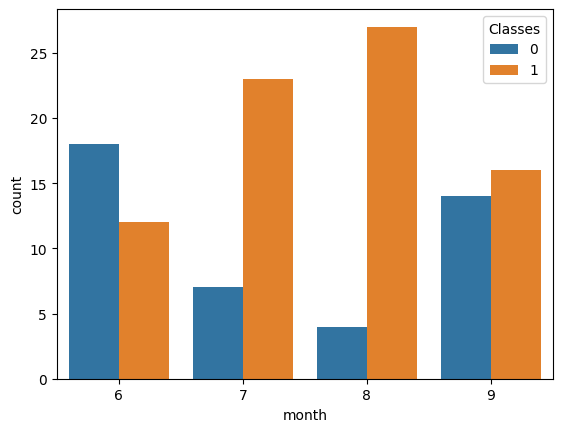

In [53]:
first=df_copy[df_copy['Region']==1]
sns.countplot(data=first,x='month',hue='Classes')

<Axes: xlabel='month', ylabel='count'>

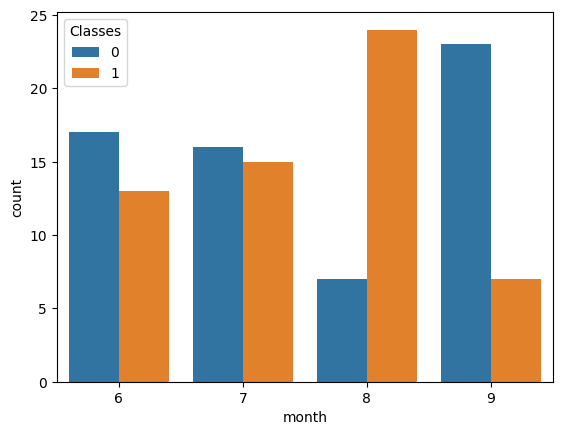

In [54]:

oh=df_copy[df_copy['Region']==0]
sns.countplot(data=oh,x='month',hue='Classes')